In [65]:
from matplotlib import pyplot as plt
import numpy as np
import json

In [66]:
method = "EM_MWG"
filename = "large_mu"
complete_filename = f"results_{method}_{filename}"

In [ ]:
with open(f"results/{complete_filename}.json", "r") as f:
    results = json.load(f)

# plot true vs estimated values for mu, eta, nu, and Theta, with MSE as error bars. Each plot should be a separate figure.
mu_true = np.array(results["nu"]["true"])
mu_est = np.array(results["nu"]["estimated"])
eta_true = np.array(results["eta"]["true"])
eta_est = np.array(results["eta"]["estimated"])
nu_true = np.array(results["nu"]["true"])
nu_est = np.array(results["nu"]["estimated"])
Theta_true = np.array(results["Theta"]["true"])
Theta_est = np.array(results["Theta"]["estimated"])
mse_mu = np.array(results["nu"]["mse"])
mse_eta = np.array(results["eta"]["mse"])
mse_nu = np.array(results["nu"]["mse"])
mse_Theta = results["Theta"]["mse"]

p = len(mu_true)

FileNotFoundError: [Errno 2] No such file or directory: 'results/large_mu.json'

In [ ]:
print(f"{'mu':>10} {np.round(mu_true, 5)} {np.round(mu_est, 5)}")
print(f"{'eta':>10} {np.round(eta_true, 5)} {np.round(eta_est, 5)}")
print(f"{'nu':>10} {np.round(nu_true, 5)} {np.round(nu_est, 5)}")
print(f"{'gamma':>10} {np.round(eta_true * nu_true, 5)} {np.round(eta_est * nu_est, 5)}")
print(f"{'mu + gamma:':>10} {np.round(mu_true + eta_true * nu_true, 5)} {np.round(mu_est + eta_est * nu_est, 5)}")
print("\nTrue Theta:\n", np.round(Theta_true, 5))
print("\nEstimated Theta:\n", np.round(Theta_est, 5))
print("\n")
print("Mean squared error for mu:", mse_mu)
print("Mean squared error for nu:", mse_nu)
print("Mean squared error for eta:", mse_eta)
print("Mean squared error for Theta:", mse_Theta)

        mu [0.7587  0.42382 0.57895 0.7113  0.37228] [0.85906 0.41662 0.55136 0.70593 0.41759]
       eta [ 0.03226 -0.96476  0.31995 -0.40646 -0.29436] [ 0.03333 -0.97285  0.43896 -0.36465 -0.24023]
        nu [0.7587  0.42382 0.57895 0.7113  0.37228] [0.85906 0.41662 0.55136 0.70593 0.41759]
     gamma [ 0.02448 -0.40888  0.18524 -0.28912 -0.10958] [ 0.02863 -0.4053   0.24203 -0.25742 -0.10032]
mu + gamma: [0.78318 0.01494 0.76419 0.42218 0.26269] [0.8877  0.01131 0.79339 0.44851 0.31727]

True Theta:
 [[2.  0.5 0.  0.  0. ]
 [0.5 2.  0.5 0.  0. ]
 [0.  0.5 2.  0.5 0. ]
 [0.  0.  0.5 2.  0.5]
 [0.  0.  0.  0.5 2. ]]

Estimated Theta:
 [[ 2.01508  0.50467 -0.01227  0.       0.00752]
 [ 0.50467  1.97805  0.5271   0.       0.01462]
 [-0.01227  0.5271   2.06004  0.47526  0.     ]
 [ 0.       0.       0.47526  2.02015  0.49879]
 [ 0.00752  0.01462  0.       0.49879  2.0983 ]]


Mean squared error for mu: [1.00724471e-02 5.19001147e-05 7.61087888e-04 2.88603001e-05
 2.05310785e-03]
Mean sq

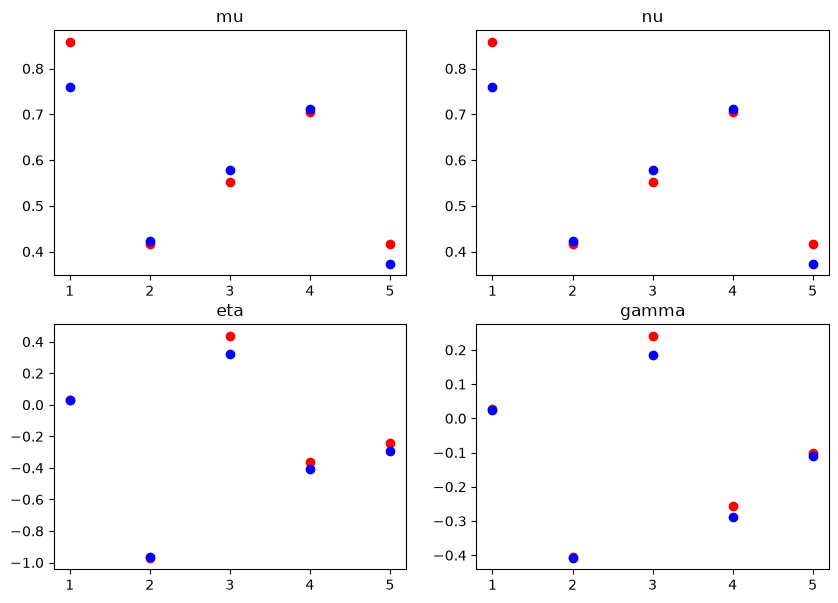

In [ ]:
# Create a plot with 4 subfigures
fig, axs = plt.subplots(2, 2, figsize = (10,7))
axs[0, 0].scatter(range(p), mu_est, color='red', label='Estimated mu')
axs[0, 0].scatter(range(p), mu_true, color='blue', label='True mu')
axs[0, 0].set_xticks(range(p), range(1, p+1))
axs[0, 0].set_title('mu')

axs[0, 1].scatter(range(p), nu_est, color='red', label='Estimated nu')
axs[0, 1].scatter(range(p), nu_true, color='blue', label='True nu')
axs[0, 1].set_xticks(range(p), range(1, p+1))
axs[0, 1].set_title('nu')

axs[1, 0].scatter(range(p), eta_est, color='red', label='Estimated eta')
axs[1, 0].scatter(range(p), eta_true, color='blue', label='True eta')
axs[1, 0].set_xticks(range(p), range(1, p+1))
axs[1, 0].set_title('eta')

axs[1, 1].scatter(range(p), nu_est * eta_est, color='red', label='Estimated gamma')
axs[1, 1].scatter(range(p), nu_true * eta_true, color='blue', label='True gamma')
axs[1, 1].set_xticks(range(p), range(1, p+1))
axs[1, 1].set_title('gamma')

fig.savefig(f"results/{filename}.pdf")

In [ ]:
# # make a p by p heatmap for Theta, where the intensity of the color represents the difference between the true and estimated values, with a colorbar to indicate the scale of the difference.
# plt.figure()
# plt.imshow(np.abs(Theta_true - Theta_est), cmap='viridis', interpolation='nearest', vmin = 0, vmax = 0.5)
# plt.colorbar()